In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib


In [ ]:
df = pd.read_csv("coupon_campaign_candidate.csv")

**EDA**


In [ ]:
df

,CAMPAIGN_ID,START_DATE,END_DATE,REWARD_TYPE,REWARD_AMOUNT_SAR,REWARD_PERCENTAGE,BUDGET,MIN_ORDER_SAR,MAX_TOTAL_USAGE,COUNTRY,RAND_FLAG,WEEKEND_SHARE,BRANCH_ORDERS_90D,BRANCH_AVG_ORDER_90D,ORDERS_BEFORE,CUSTOMERS_BEFORE,CAMPAIGN_REVENUE_SAR
0,1389067,"Jan 31, 2026","Mar 03, 2026",percent,43.08,38,"2,410",0.00,0,SA,0,0.2080,521,58,475,308,92530.53
1,1370063,2025-11-25,07/01/2026,percentage,47.96,44,114,43.18,2000,SA,1,0.2329,73,39,47,44,18839.80
2,1383246,2025-12-08 00:00:00,2025-12-17,PERCENT,16.78,35,"1,190",0.00,0,SA,0,0.3656,600,29,400,338,33336.37
3,1387803,2026-03-22,"Apr 05, 2026",percentage,16.97,11,2682 SAR,100.18,0,SA,0,0.2653,562,43,574,488,18306.86
4,1380537,2025-09-28,"Nov 22, 2025",PERCENT,12.19,28,417 SAR,113.47,0,SA,0,0.2614,35,50,76,54,27174.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20395,1336060,2026-01-05 00:00:00,2026-01-20 00:00:00,Fixed,17.22,47,7204,0.00,2000,SA,1,0.2914,823,47,825,686,35653.79
20396,1336190,2026-03-08,2026-04-15 00:00:00,PERCENT,37.57,12,77 SAR,0.00,5000,SA,1,0.2122,27,85,33,25,22658.73
20397,1351059,17/12/2025,2026-02-22 00:00:00,percent,43.34,48,581 SAR,0.00,2000,SA,1,0.3205,97,43,186,130,94631.34
20398,1388255,2025-09-02,03/11/2025,PERCENT,24.51,6,"2,937 SAR",0.00,0,SA,1,0.3281,552,86,730,585,128712.46


From the above, it tells me that the data contains 20,400 rows and 17 columns.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CAMPAIGN_ID           20400 non-null  int64  
 1   START_DATE            20400 non-null  object 
 2   END_DATE              20400 non-null  object 
 3   REWARD_TYPE           20400 non-null  object 
 4   REWARD_AMOUNT_SAR     20400 non-null  float64
 5   REWARD_PERCENTAGE     20400 non-null  int64  
 6   BUDGET                20400 non-null  object 
 7   MIN_ORDER_SAR         20400 non-null  float64
 8   MAX_TOTAL_USAGE       20400 non-null  int64  
 9   COUNTRY               20400 non-null  object 
 10  RAND_FLAG             20400 non-null  int64  
 11  WEEKEND_SHARE         20400 non-null  float64
 12  BRANCH_ORDERS_90D     20400 non-null  object 
 13  BRANCH_AVG_ORDER_90D  20400 non-null  int64  
 14  ORDERS_BEFORE         20400 non-null  object 
 15  CUSTOMERS_BEFORE   

In [ ]:
df.describe()#This helps me with many things such as detecting outliers and others

,CAMPAIGN_ID,REWARD_AMOUNT_SAR,REWARD_PERCENTAGE,MIN_ORDER_SAR,MAX_TOTAL_USAGE,RAND_FLAG,WEEKEND_SHARE,BRANCH_AVG_ORDER_90D,CAMPAIGN_REVENUE_SAR
count,2.040000e+04,20400.000000,20400.000000,20400.00000,20400.000000,20400.000000,20400.000000,20400.000000,2.040000e+04
mean,1.349920e+06,32.394959,27.353088,53.19214,1765.299118,0.497206,0.281128,47.838137,1.392650e+05
std,2.878001e+04,15.970726,13.302028,50.16876,2040.413219,0.500004,0.059840,17.365177,3.128544e+06
min,1.300002e+06,-56.600000,5.000000,0.00000,0.000000,0.000000,0.051100,12.000000,-3.968400e+03
25%,1.324987e+06,18.600000,16.000000,0.00000,1.000000,0.000000,0.240500,35.000000,1.963022e+04
50%,1.349645e+06,32.455000,27.000000,45.42000,2000.000000,0.000000,0.280600,45.000000,3.211259e+04
75%,1.374720e+06,46.260000,39.000000,96.87500,2000.000000,1.000000,0.321900,57.000000,5.230419e+04
max,1.399998e+06,60.000000,50.000000,149.99000,5000.000000,1.000000,0.519900,193.000000,1.000000e+08


In [ ]:
print(df.isnull().any())
print(df.isnull().sum())
#Here in this section I am only doing exploration the cleaning will be done in the preprocessing section

CAMPAIGN_ID             False
START_DATE              False
END_DATE                False
REWARD_TYPE             False
REWARD_AMOUNT_SAR       False
REWARD_PERCENTAGE       False
BUDGET                  False
MIN_ORDER_SAR           False
MAX_TOTAL_USAGE         False
COUNTRY                 False
RAND_FLAG               False
WEEKEND_SHARE           False
BRANCH_ORDERS_90D       False
BRANCH_AVG_ORDER_90D    False
ORDERS_BEFORE           False
CUSTOMERS_BEFORE         True
CAMPAIGN_REVENUE_SAR    False
dtype: bool
CAMPAIGN_ID               0
START_DATE                0
END_DATE                  0
REWARD_TYPE               0
REWARD_AMOUNT_SAR         0
REWARD_PERCENTAGE         0
BUDGET                    0
MIN_ORDER_SAR             0
MAX_TOTAL_USAGE           0
COUNTRY                   0
RAND_FLAG                 0
WEEKEND_SHARE             0
BRANCH_ORDERS_90D         0
BRANCH_AVG_ORDER_90D      0
ORDERS_BEFORE             0
CUSTOMERS_BEFORE        329
CAMPAIGN_REVENUE_SAR      0
dt

In [ ]:
print(df[df.duplicated()])
#Here in this section I am only doing exploration the cleaning will be done in the preprocessing section

       CAMPAIGN_ID           START_DATE             END_DATE REWARD_TYPE  \
382        1339778         Sep 11, 2025  2025-10-27 00:00:00    percent    
536        1323432           2025-11-26  2026-01-14 00:00:00     PERCENT   
686        1374973           05/11/2025  2025-11-21 00:00:00       Fixed   
729        1306094  2026-02-11 00:00:00  2026-03-24 00:00:00     PERCENT   
869        1326839           2026-02-22         May 13, 2026  percentage   
...            ...                  ...                  ...         ...   
20272      1339456  2025-12-06 00:00:00           06/02/2026       Fixed   
20294      1306584         Mar 02, 2026         Mar 24, 2026  percentage   
20303      1327504  2025-11-21 00:00:00         Dec 09, 2025       Fixed   
20388      1311644           2026-03-29           02/05/2026     PERCENT   
20393      1340333  2026-01-15 00:00:00  2026-03-01 00:00:00    percent    

       REWARD_AMOUNT_SAR  REWARD_PERCENTAGE     BUDGET  MIN_ORDER_SAR  \
382           

so we have 400 duplicate rows

**Data** **preprocessing**

In [ ]:
df["START_DATE"] = pd.to_datetime(df["START_DATE"], errors="coerce", format="mixed")
df["END_DATE"]   = pd.to_datetime(df["END_DATE"], errors="coerce", format="mixed")
df

,CAMPAIGN_ID,START_DATE,END_DATE,REWARD_TYPE,REWARD_AMOUNT_SAR,REWARD_PERCENTAGE,BUDGET,MIN_ORDER_SAR,MAX_TOTAL_USAGE,COUNTRY,RAND_FLAG,WEEKEND_SHARE,BRANCH_ORDERS_90D,BRANCH_AVG_ORDER_90D,ORDERS_BEFORE,CUSTOMERS_BEFORE,CAMPAIGN_REVENUE_SAR
0,1389067,2026-01-31,2026-03-03,percent,43.08,38,"2,410",0.00,0,SA,0,0.2080,521,58,475,308,92530.53
1,1370063,2025-11-25,2026-07-01,percentage,47.96,44,114,43.18,2000,SA,1,0.2329,73,39,47,44,18839.80
2,1383246,2025-12-08,2025-12-17,PERCENT,16.78,35,"1,190",0.00,0,SA,0,0.3656,600,29,400,338,33336.37
3,1387803,2026-03-22,2026-04-05,percentage,16.97,11,2682 SAR,100.18,0,SA,0,0.2653,562,43,574,488,18306.86
4,1380537,2025-09-28,2025-11-22,PERCENT,12.19,28,417 SAR,113.47,0,SA,0,0.2614,35,50,76,54,27174.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20395,1336060,2026-01-05,2026-01-20,Fixed,17.22,47,7204,0.00,2000,SA,1,0.2914,823,47,825,686,35653.79
20396,1336190,2026-03-08,2026-04-15,PERCENT,37.57,12,77 SAR,0.00,5000,SA,1,0.2122,27,85,33,25,22658.73
20397,1351059,2025-12-17,2026-02-22,percent,43.34,48,581 SAR,0.00,2000,SA,1,0.3205,97,43,186,130,94631.34
20398,1388255,2025-09-02,2025-03-11,PERCENT,24.51,6,"2,937 SAR",0.00,0,SA,1,0.3281,552,86,730,585,128712.46


In [ ]:
numericColumns=["BUDGET","MIN_ORDER_SAR","REWARD_AMOUNT_SAR","REWARD_PERCENTAGE",
                "MAX_TOTAL_USAGE","WEEKEND_SHARE","BRANCH_ORDERS_90D", "BRANCH_AVG_ORDER_90D","ORDERS_BEFORE",
                "CUSTOMERS_BEFORE","CAMPAIGN_REVENUE_SAR"]
for col in numericColumns:
    df[col] = (df[col].astype(str)
        .str.upper()
        .str.replace("SAR", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip())
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [ ]:
df["REWARD_TYPE"] = df["REWARD_TYPE"].str.lower().str.strip()
df["REWARD_TYPE"] = df["REWARD_TYPE"].replace({"percent": "percentage"})

In [ ]:
df ["REWARD_TYPE"].astype(str).str.strip().value_counts()

,count
REWARD_TYPE,
percentage,16268
fixed,4132


In [ ]:
df=df[df["CAMPAIGN_REVENUE_SAR"] >= 0]
df=df[df["CAMPAIGN_REVENUE_SAR"] != 99999999]
df=df[df["REWARD_AMOUNT_SAR"] >= 0]
df=df[df["END_DATE"] >= df["START_DATE"]] #Remove rows where the end date is earlier than the start date

In [ ]:
le = LabelEncoder()
df["REWARD_TYPE"]=le.fit_transform(df["REWARD_TYPE"])

In [ ]:
for col in df.columns:
    if df[col].isnull().any():

        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])#these two raws i put it to ensure double guarantee

        else:
            df[col] = df[col].fillna(df[col].mean())

In [ ]:
print(df.isnull().any())
print(df.isnull().sum())

CAMPAIGN_ID             False
START_DATE              False
END_DATE                False
REWARD_TYPE             False
REWARD_AMOUNT_SAR       False
REWARD_PERCENTAGE       False
BUDGET                  False
MIN_ORDER_SAR           False
MAX_TOTAL_USAGE         False
COUNTRY                 False
RAND_FLAG               False
WEEKEND_SHARE           False
BRANCH_ORDERS_90D       False
BRANCH_AVG_ORDER_90D    False
ORDERS_BEFORE           False
CUSTOMERS_BEFORE        False
CAMPAIGN_REVENUE_SAR    False
dtype: bool
CAMPAIGN_ID             0
START_DATE              0
END_DATE                0
REWARD_TYPE             0
REWARD_AMOUNT_SAR       0
REWARD_PERCENTAGE       0
BUDGET                  0
MIN_ORDER_SAR           0
MAX_TOTAL_USAGE         0
COUNTRY                 0
RAND_FLAG               0
WEEKEND_SHARE           0
BRANCH_ORDERS_90D       0
BRANCH_AVG_ORDER_90D    0
ORDERS_BEFORE           0
CUSTOMERS_BEFORE        0
CAMPAIGN_REVENUE_SAR    0
dtype: int64


In [ ]:
df.drop_duplicates(inplace=True)

print(df[df.duplicated()])#i like to check always

Empty DataFrame
Columns: [CAMPAIGN_ID, START_DATE, END_DATE, REWARD_TYPE, REWARD_AMOUNT_SAR, REWARD_PERCENTAGE, BUDGET, MIN_ORDER_SAR, MAX_TOTAL_USAGE, COUNTRY, RAND_FLAG, WEEKEND_SHARE, BRANCH_ORDERS_90D, BRANCH_AVG_ORDER_90D, ORDERS_BEFORE, CUSTOMERS_BEFORE, CAMPAIGN_REVENUE_SAR]
Index: []


In [ ]:
# Check for statistical outliers in revenue (exploration only, not removal)
Q1 = df["CAMPAIGN_REVENUE_SAR"].quantile(0.25)
Q3 = df["CAMPAIGN_REVENUE_SAR"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outlier_count = ((df["CAMPAIGN_REVENUE_SAR"] < lower) |
                  (df["CAMPAIGN_REVENUE_SAR"] > upper)).sum()
print(f"Potential outliers by IQR rule: {outlier_count} rows "
      f"({outlier_count/len(df)*100:.1f}% of data)")

Potential outliers by IQR rule: 975 rows (5.4% of data)


The IQR rule flags about 5.4% of campaigns as statistical outliers in
revenue. These were not removed, since they likely represent genuinely
high performing campaigns rather than data errors, and removing them
would bias the model against predicting exactly the high revenue
campaigns the business cares most about. Tree based models such as
XGBoost are also naturally robust to this kind of variance.

**Feature Engineering**

In [ ]:
# Here I calculate the campaign duration in days because I will use it as a feature
df["DURATION_DAYS"]= (df["END_DATE"] - df["START_DATE"]).dt.days

# Here I extract the start month since it might have an impact
df["START_MONTH"]=df["START_DATE"].dt.month

# Here I check if the usage is uncapped (0 means unlimited)
df["USAGE_UNCAPPED"]= (df["MAX_TOTAL_USAGE"] == 0).astype(int)

# Here I calculate the budget per usage, and if usage is unlimited I use the full budget
df["BUDGET_PER_USAGE"]= np.where(
    df["MAX_TOTAL_USAGE"] == 0,
    df["BUDGET"],
    df["BUDGET"] / df["MAX_TOTAL_USAGE"])


Feature Engineering Explanation:
- DURATION_DAYS: Campaign length affects customer exposure.
- START_MONTH: Seasonality may influence campaign performance.
- USAGE_UNCAPPED: Unlimited usage campaigns behave differently.
- BUDGET_PER_USAGE: Helps normalize budget relative to allowed usage.


In [ ]:
# Here I select the columns that I want to use as features for the model
features = ["REWARD_TYPE", "REWARD_AMOUNT_SAR",
    "REWARD_PERCENTAGE", "BUDGET",
    "MIN_ORDER_SAR", "MAX_TOTAL_USAGE",
    "WEEKEND_SHARE", "BRANCH_ORDERS_90D",
    "BRANCH_AVG_ORDER_90D", "ORDERS_BEFORE",
    "CUSTOMERS_BEFORE", "DURATION_DAYS",
    "START_MONTH", "USAGE_UNCAPPED", "BUDGET_PER_USAGE"]


Feature Selection Rationale:
The selected features combine reward configuration, branch historical
behavior, and campaign structure. Historical features such as ORDERS_BEFORE
and BRANCH_AVG_ORDER_90D are included because they strongly influence
expected revenue. Campaign structure features (DURATION_DAYS, START_MONTH,
USAGE_UNCAPPED) capture operational differences between campaigns. Reward
features (percentage and amount) represent the incentive strength. These
features collectively provide the model with both behavioral and business
context.

Note: COUNTRY and RAND_FLAG were reviewed and excluded because they do not
provide predictive value. Although BUDGET and BUDGET_PER_USAGE are
correlated, tree-based models like XGBoost handle multicollinearity well, so
no additional processing was required.


Although some features such as BUDGET and BUDGET_PER_USAGE are
correlated, tree based models like XGBoost handle multicollinearity well,
so no additional processing was required.


In [ ]:
# Here I separate the features from the target variable
X = df[features]
y = df["CAMPAIGN_REVENUE_SAR"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Modeling**

In [ ]:
# Here I start with a simple baseline model to know the minimum performance
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)

mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)

print("Linear Regression Performance:")
print("MAE:",mae_lr)
print("RMSE:",rmse_lr)
print("R2:",r2_lr)

Linear Regression Performance:
MAE: 14514.051537860209
RMSE: 22488.97066023222
R2: 0.5300736631944236


I applied scaling only to the Linear Regression model because it is sensitive to differences in feature magnitude.
Tree based models like Random Forest and XGBoost do not require scaling, so they were trained on the original data.
Scaling was fitted on the training set only to avoid data leakage and then applied to the test set.


In [ ]:
# Here i build a stronger non linear model to see how much improvement I get over the baseline
rf = RandomForestRegressor(n_estimators=300,   # number of trees
    max_depth=None,     # let the trees grow fully
    random_state=42     # for reproducibility
)

#  i train the Random Forest model
rf.fit(X_train, y_train)

#  Then i make predictions using the Random Forest model
pred_rf= rf.predict(X_test)

# next i evaluate the model using MAE, RMSE, and R2
mae_rf= mean_absolute_error(y_test, pred_rf)
rmse_rf= np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf= r2_score(y_test, pred_rf)

print("Random Forest Performance:")
print("MAE:",mae_rf)
print("RMSE:",rmse_rf)
print("R2:",r2_rf)

Random Forest Performance:
MAE: 7862.212705636027
RMSE: 13621.613567676119
R2: 0.8275958399336123


In [ ]:
# Here I build a powerful gradient boosting model because this type usually performs best on structured data
xgb= XGBRegressor(n_estimators=500,       # number of boosting rounds
    learning_rate=0.05,    # smaller learning rate for better stability
    max_depth=6,           # depth of each tree
    subsample=0.8,         # sample ratio for each tree
    colsample_bytree=0.8,  # feature sampling ratio
    random_state=42        # reproducibility
                   )

# train the XGBoost model
xgb.fit(X_train, y_train)

# then i make predictions using the XGBoost model
pred_xgb= xgb.predict(X_test)

#next i evaluate the model using MAE, RMSE, and R2
mae_xgb= mean_absolute_error(y_test, pred_xgb)
rmse_xgb= np.sqrt(mean_squared_error(y_test, pred_xgb))
r2_xgb= r2_score(y_test, pred_xgb)

print("XGBoost Performance:")
print("MAE:",mae_xgb)
print("RMSE:",rmse_xgb)
print("R2:",r2_xgb)

XGBoost Performance:
MAE: 5741.002743444161
RMSE: 10684.136350427729
R2: 0.8939356405500231


In [ ]:
# Here I build a naive baseline that always predicts the average campaign revenue
avg_revenue= y_train.mean()

# then i create predictions using only the average revenue
pred_naive= np.full_like(y_test, fill_value=avg_revenue, dtype=float)

#next i evaluate the naive baseline
mae_naive= mean_absolute_error(y_test, pred_naive)
rmse_naive= np.sqrt(mean_squared_error(y_test, pred_naive))
r2_naive= r2_score(y_test, pred_naive)

print("Naive Baseline with Average Revenue Performance:")
print("MAE:",mae_naive)
print("RMSE:",rmse_naive)
print("R2:",r2_naive)

Naive Baseline with Average Revenue Performance:
MAE: 23167.665693580122
RMSE: 32806.18687994996
R2: -4.924936676919955e-06


Hyperparameter Tuning

In [ ]:
rf_params={ "n_estimators": [100, 200, 300],"max_depth": [ 10, 20, None],"min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]}

rf_search= RandomizedSearchCV(RandomForestRegressor(random_state=42), rf_params, n_iter=10,
    scoring="neg_mean_absolute_error",cv=3,random_state=42,n_jobs=-1)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
print("Best Random Forest Parameters:")
print(rf_search.best_params_)

# Evaluate tuned Random Forest
pred_rf= best_rf.predict(X_test)

mae_rf= mean_absolute_error(y_test, pred_rf)
rmse_rf= np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf= r2_score(y_test, pred_rf)

print("Tuned Random Forest Performance:")
print("MAE:",mae_rf)
print("RMSE:",rmse_rf)
print("R2:",r2_rf)

Best Random Forest Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Tuned Random Forest Performance:
MAE: 7862.212705636027
RMSE: 13621.613567676119
R2: 0.8275958399336123


The initial hyperparameter search was too large and caused runtime errors, so
I reduced the parameter grid to ensure stable execution. The smaller search
still improves the model while keeping the training time manageable.


In [ ]:
xgb_params= {"n_estimators": [100, 200, 300], "learning_rate": [0.05, 0.1],
    "max_depth": [4, 6],"subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]}

xgb_search= RandomizedSearchCV( XGBRegressor(random_state=42), xgb_params,
    n_iter=10,
    scoring="neg_mean_absolute_error", cv=3,
    random_state=42,n_jobs=-1)

xgb_search.fit(X_train, y_train)
best_xgb= xgb_search.best_estimator_
print("Best XGBoost Parameters:")
print(xgb_search.best_params_)

pred_xgb= best_xgb.predict(X_test)

mae_xgb= mean_absolute_error(y_test, pred_xgb)
rmse_xgb= np.sqrt(mean_squared_error(y_test, pred_xgb))
r2_xgb= r2_score(y_test, pred_xgb)
# Evaluate tuned XGBoost
print("Tuned XGBoost Performance:")
print("MAE:",mae_xgb)
print("RMSE:",rmse_xgb)
print("R2:",r2_xgb)

Best XGBoost Parameters:
{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Tuned XGBoost Performance:
MAE: 6325.754686365876
RMSE: 11193.419927338431
R2: 0.8835830482538913


Model Evaluation  Comparison

In [ ]:
results= pd.DataFrame({"Model": ["Naive Baseline", "Linear Regression", "Random Forest (Tuned)", "XGBoost (Tuned)"],
    "MAE": [mae_naive, mae_lr, mae_rf, mae_xgb],
    "RMSE": [rmse_naive, rmse_lr, rmse_rf, rmse_xgb],
    "R2": [r2_naive, r2_lr, r2_rf, r2_xgb]})
print(results)


                   Model           MAE          RMSE        R2
0         Naive Baseline  23167.665694  32806.186880 -0.000005
1      Linear Regression  14514.051538  22488.970660  0.530074
2  Random Forest (Tuned)   7862.212706  13621.613568  0.827596
3        XGBoost (Tuned)   6325.754686  11193.419927  0.883583


Final Model Selection

Based on the comparison table, the tuned XGBoost model achieved the
lowest MAE and RMSE and the highest R2 (0.883). This means it explains
88% of the variance in campaign revenue, outperforming all other models
including Random Forest and Linear Regression. Therefore, XGBoost is
selected as the final model.


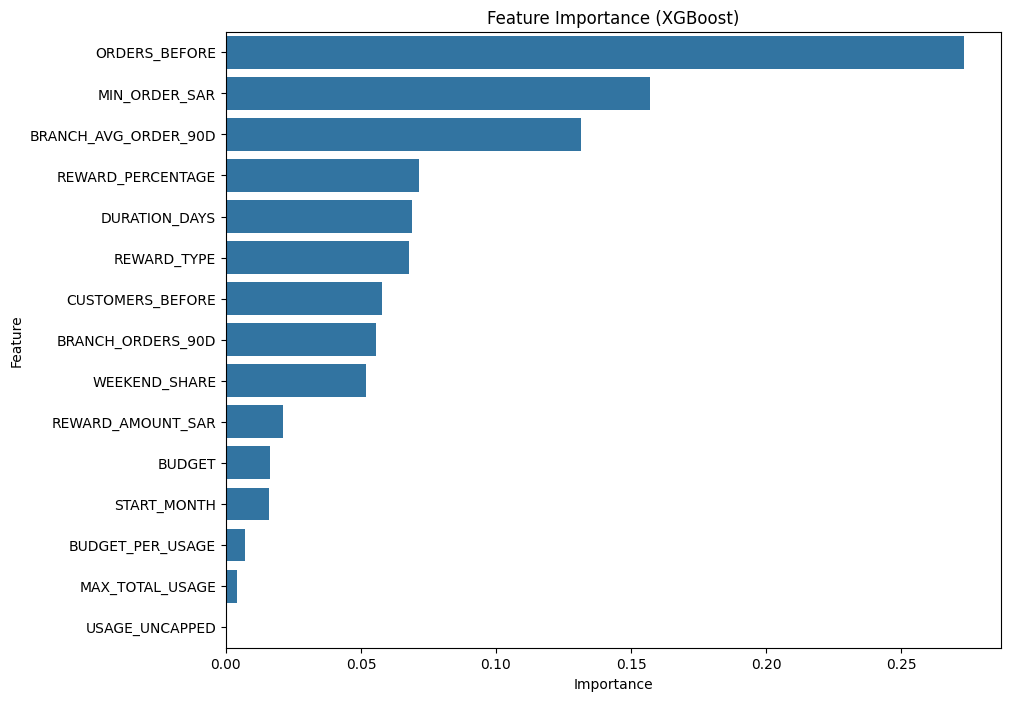

,Feature,Importance
9,ORDERS_BEFORE,0.273271
4,MIN_ORDER_SAR,0.156969
8,BRANCH_AVG_ORDER_90D,0.131377
2,REWARD_PERCENTAGE,0.071644
11,DURATION_DAYS,0.069012
0,REWARD_TYPE,0.067805
10,CUSTOMERS_BEFORE,0.057715
7,BRANCH_ORDERS_90D,0.055661
6,WEEKEND_SHARE,0.051802
1,REWARD_AMOUNT_SAR,0.021313


In [ ]:
# Here I calculate feature importance from the best model (XGBoost)
importance=pd.DataFrame({"Feature": X_train.columns,"Importance": best_xgb.feature_importances_})

# Sort by importance
importance = importance.sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance, x="Importance", y="Feature")
plt.title("Feature Importance (XGBoost)")
plt.show()

importance#to shiw the table


The feature importance results show that historical branch activity
(ORDERS_BEFORE, MIN_ORDER_SAR, BRANCH_AVG_ORDER_90D) has the strongest
impact on campaign revenue.This indicates that past customer behavior
and branch performance are more predictive than reward configuration
alone. Reward features still matter, but operational and behavioral
features drive most of the model’s predictive power.


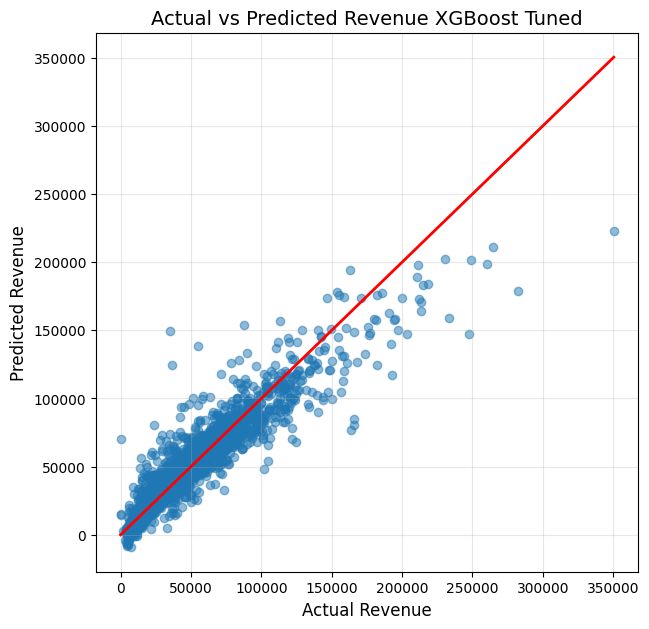

In [ ]:
plt.figure(figsize=(7,7))
# Here I plot actual vs predicted revenue to see how close the model is to reality
plt.scatter( y_test, pred_xgb, alpha=0.5, color="#1f77b4")

# Here I draw the perfect prediction line (ideal model)
plt.plot( [y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red",linewidth=2)

plt.xlabel("Actual Revenue", fontsize=12)
plt.ylabel("Predicted Revenue", fontsize=12)
plt.title("Actual vs Predicted Revenue XGBoost Tuned", fontsize=14)
plt.grid(alpha=0.3)

plt.show()



The scatter plot shows that most predicted values are close to the actual revenues, forming a pattern around the ideal red line. This indicates that the tuned XGBoost model captures the relationship between features and revenue effectively.
Some deviation is more noticeable at higher revenue values, which is explored further in the residual plot below.


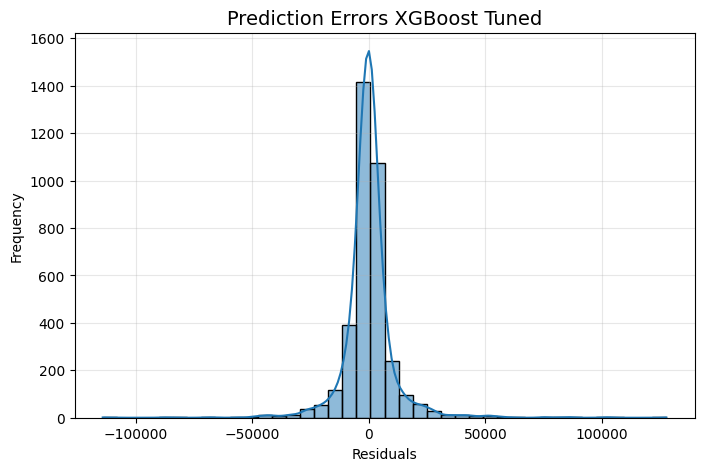

In [ ]:
errors = y_test - pred_xgb

plt.figure(figsize=(8,5))
sns.histplot(errors,bins=40, kde=True,color="#1f77b4")
plt.title("Prediction Errors XGBoost Tuned", fontsize=14)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()


The error distribution is centered around zero, meaning the model does
not systematically overestimate or underestimate revenue overall.
However, as shown in the residual plot below, the size of these errors
is not constant across all prediction ranges.

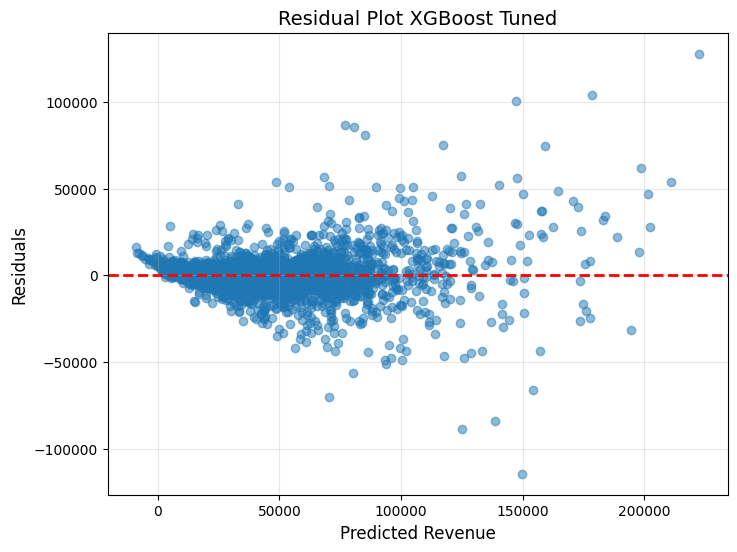

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(pred_xgb,errors,alpha=0.5, color="#1f77b4")

plt.axhline(0,color="red",linestyle="--",linewidth=2)

plt.xlabel("Predicted Revenue", fontsize=12)
plt.ylabel("Residuals", fontsize=12)
plt.title("Residual Plot XGBoost Tuned", fontsize=14)
plt.grid(alpha=0.3)

plt.show()


The residuals are centered around zero on average, but their spread
increases noticeably at higher predicted revenue values, forming a
funnel like pattern. This heteroscedasticity suggests the model is
less precise for high-revenue campaigns than for lower-revenue ones.
A log-transform of the target could help stabilize this variance in
future iterations (see Next Steps).

In [ ]:
# Save the final tuned XGBoost model for future use
joblib.dump(best_xgb, "best_campaign_model.pkl")
print("Model saved successfully as best_campaign_model.pkl")

Model saved successfully as best_campaign_model.pkl


Final Summary

This notebook demonstrates a complete workflow, from raw and messy data
to a validated revenue prediction model. The tuned XGBoost model, with
R2 of about 0.88 and MAE of about 6325 SAR, meaningfully outperforms
both the naive baseline and simpler models, driven primarily by
historical branch and customer behavior rather than reward
configuration alone. See the Executive Summary at the top of this
notebook for full details on data issues, assumptions, and next steps.